# Te-121 — counting efficiency with the stochastic model

Te-121 decays 100% by electron capture (T1/2 = 19.17 d) to excited levels of Sb-121. There is no beta continuous spectrum, so the fast analytical model (`effA`/`modelAnalytical`) is not available for this nuclide — only the full stochastic Monte Carlo model can be used, in the same way as for Fe-55 or Cd-109.

In [ ]:
pip install TDCRPy==2.20.17

In [1]:
import tdcrpy as td
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
Rad = "Te-121"               # radionuclide
pmf_1 = "1"                  # relative activity fraction
kB = 1.0e-5                  # Birks constant in cm keV-1
V = 10                       # volume of scintillator in mL

## Efficiency at a fixed light yield

Forward computation: run the stochastic model at a given free parameter `L` (light yield, photon keV⁻¹) and report the counting efficiencies (single S, double D, triple T, and the three double coincidence channels AB/BC/AC) with their Monte Carlo standard uncertainties.

In [3]:
L = 5      # light yield, photon keV-1
N = 2000   # number of Monte-Carlo trials

result = td.TDCRPy.TDCRPy(L, Rad, pmf_1, N, kB, V, mode="eff")

eff_S, u_S, eff_D, u_D, eff_T, u_T, eff_AB, u_AB, eff_BC, u_BC, eff_AC, u_AC, eff_D2, u_D2 = result

print(f"efficiency S  = {eff_S:.4f} +/- {u_S:.4f}")
print(f"efficiency D  = {eff_D:.4f} +/- {u_D:.4f}")
print(f"efficiency T  = {eff_T:.4f} +/- {u_T:.4f}")
print(f"efficiency AB = {eff_AB:.4f} +/- {u_AB:.4f}")
print(f"efficiency BC = {eff_BC:.4f} +/- {u_BC:.4f}")
print(f"efficiency AC = {eff_AC:.4f} +/- {u_AC:.4f}")

efficiency S  = 0.8108 +/- 0.0072
efficiency D  = 0.6169 +/- 0.0070
efficiency T  = 0.3840 +/- 0.0088
efficiency AB = 0.4617 +/- 0.0080
efficiency BC = 0.4617 +/- 0.0080
efficiency AC = 0.4617 +/- 0.0080


## Efficiency curve vs. light yield

Scan the free parameter `L` to build the efficiency curves S(L), D(L) and T(L). This is the curve normally used to bracket the counting efficiency for a given cocktail/instrument once the free parameter has been calibrated against a reference source.

In [4]:
L_scan = [0.5, 1, 2, 3, 5, 8, 12]
N_scan = 500

eff_S_l, u_S_l = [], []
eff_D_l, u_D_l = [], []
eff_T_l, u_T_l = [], []

for L_i in tqdm(L_scan):
    r = td.TDCRPy.TDCRPy(L_i, Rad, pmf_1, N_scan, kB, V, mode="eff")
    eff_S_l.append(r[0]); u_S_l.append(r[1])
    eff_D_l.append(r[2]); u_D_l.append(r[3])
    eff_T_l.append(r[4]); u_T_l.append(r[5])

  0%|          | 0/7 [00:00<?, ?it/s]

 14%|█▍        | 1/7 [00:09<00:55,  9.33s/it]

 29%|██▊       | 2/7 [00:18<00:47,  9.41s/it]

 43%|████▎     | 3/7 [00:27<00:36,  9.24s/it]

 57%|█████▋    | 4/7 [00:37<00:27,  9.27s/it]

 71%|███████▏  | 5/7 [00:46<00:18,  9.28s/it]

 86%|████████▌ | 6/7 [00:55<00:09,  9.25s/it]

100%|██████████| 7/7 [01:04<00:00,  9.25s/it]

100%|██████████| 7/7 [01:04<00:00,  9.27s/it]

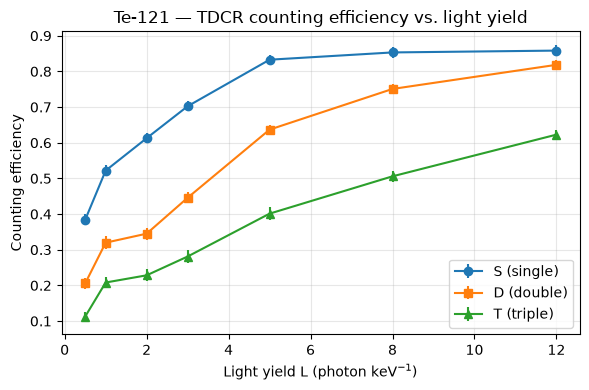

In [5]:
plt.figure(figsize=(6, 4))
plt.errorbar(L_scan, eff_S_l, yerr=u_S_l, marker="o", label="S (single)")
plt.errorbar(L_scan, eff_D_l, yerr=u_D_l, marker="s", label="D (double)")
plt.errorbar(L_scan, eff_T_l, yerr=u_T_l, marker="^", label="T (triple)")
plt.xlabel("Light yield L (photon keV$^{-1}$)")
plt.ylabel("Counting efficiency")
plt.title(f"{Rad} — TDCR counting efficiency vs. light yield")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()